# Stop-and-Go Swarm Data Analysis

This notebook analyses the recorded stop-and-go CSV files from `A` to `V`

In [8]:
from pathlib import Path
from matplotlib.patches import Patch
import csv
import math
import statistics
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
CONFIG_PATH = PROJECT_ROOT / 'stop_go_exp_config.csv'

if not CONFIG_PATH.exists():
    raise FileNotFoundError(
        'stop_go_exp_config.csv was not found. Open this notebook from the argos_project_obs folder.'
    )

PLOT_DIR = PROJECT_ROOT / 'graphics' / 'plots'
SAVE_FIGURES = True

if SAVE_FIGURES:
    PLOT_DIR.mkdir(parents=True, exist_ok=True)

style_name = 'seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'seaborn-whitegrid'
plt.style.use(style_name)
plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 200,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'legend.fontsize': 8,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})

ROBOT_COLORS = {
    25: '#4E79A7',
    50: '#F28E2B',
    100: '#59A14F',
}

WAIT_COLORS = {
    10: '#4E79A7',
    50: '#A0CBE8',
    100: '#F28E2B',
    150: '#59A14F',
    200: '#B07AA1',
}

def save_figure(fig, filename):
    if SAVE_FIGURES:
        fig.savefig(PLOT_DIR / filename, bbox_inches='tight')

## Load CSV Data

The run labels `A` to `V` come from the CSV file names. The experiment configuration table is joined with the recorded time-series data.

In [9]:
EXPECTED_LABELS = [chr(code) for code in range(ord('A'), ord('V') + 1)]

def label_from_csv(filename):
    return Path(filename.strip()).stem.replace('stop_and_go_data', '')

configs = {}

with CONFIG_PATH.open(newline='') as handle:
    reader = csv.DictReader(handle, skipinitialspace=True)
    for row in reader:
        label = label_from_csv(row['CSVFile'])
        configs[label] = {
            'Run': label,
            'ExpNumber': int(row['ExpNumber']),
            'StoppingDistance': float(row['StoppingDistance']),
            'MaxStopTime': int(row['MaxStopTime']),
            'NumRobots': int(row['NumRobots']),
            'NumObstacles': int(row['NumObstacles']),
            'CSVFile': row['CSVFile'].strip(),
        }

missing_configs = [label for label in EXPECTED_LABELS if label not in configs]
if missing_configs:
    raise ValueError(f'Missing configurations for runs: {missing_configs}')

runs = {}

for label in EXPECTED_LABELS:
    csv_path = PROJECT_ROOT / configs[label]['CSVFile']
    if not csv_path.exists():
        raise FileNotFoundError(f'Missing data file for run {label}: {csv_path}')

    records = []
    with csv_path.open(newline='') as handle:
        reader = csv.DictReader(handle)
        for row in reader:
            records.append({
                'Tick': int(row['Tick']),
                'StoppedRobots': int(row['StoppedRobots']),
                'AvgDistance': float(row['AvgDistance']),
            })

    if not records:
        raise ValueError(f'Run {label} has no data rows')

    runs[label] = records

print(f'Loaded {len(runs)} runs: {EXPECTED_LABELS[0]} to {EXPECTED_LABELS[-1]}')

Loaded 22 runs: A to V


## Summary Metrics

The plots use a few simple metrics:

- `AvgDistanceDecreasePct`: positive values mean the final average pairwise robot distance is lower than at the start.
- `FinalStoppedPct`: percentage of robots stopped at the end of the recorded run.
- `T90StoppedTick`: first tick where at least 90% of the robots are stopped.
- `TailAvgDistanceStd`: variation of average distance in the last 10% of each run, used as a simple stability indicator.

In [10]:
def tail(values, fraction=0.10):
    count = max(10, int(len(values) * fraction))
    return values[-count:]

def first_tick_at_stopped_fraction(records, num_robots, fraction=0.90):
    threshold = num_robots * fraction
    for record in records:
        if record['StoppedRobots'] >= threshold:
            return record['Tick']
    return None

def downsample(records, max_points=400):
    if len(records) <= max_points:
        return records
    step = math.ceil(len(records) / max_points)
    sampled = records[::step]
    if sampled[-1]['Tick'] != records[-1]['Tick']:
        sampled.append(records[-1])
    return sampled

def config_tuple(label):
    cfg = configs[label]
    return (
        cfg['StoppingDistance'],
        cfg['MaxStopTime'],
        cfg['NumRobots'],
        cfg['NumObstacles'],
    )

summary = []

for label in EXPECTED_LABELS:
    cfg = configs[label]
    records = runs[label]
    avg_values = [record['AvgDistance'] for record in records]
    stopped_values = [record['StoppedRobots'] for record in records]
    tail_avg_values = tail(avg_values)

    initial_avg = avg_values[0]
    final_avg = avg_values[-1]
    avg_decrease_pct = 100.0 * (initial_avg - final_avg) / initial_avg
    final_stopped_pct = 100.0 * stopped_values[-1] / cfg['NumRobots']
    max_stopped_pct = 100.0 * max(stopped_values) / cfg['NumRobots']
    tail_avg_std = statistics.stdev(tail_avg_values) if len(tail_avg_values) > 1 else 0.0

    summary.append({
        **cfg,
        'Ticks': records[-1]['Tick'],
        'InitialAvgDistance': initial_avg,
        'FinalAvgDistance': final_avg,
        'MinAvgDistance': min(avg_values),
        'AvgDistanceDecreasePct': avg_decrease_pct,
        'FinalStoppedPct': final_stopped_pct,
        'MaxStoppedPct': max_stopped_pct,
        'T90StoppedTick': first_tick_at_stopped_fraction(records, cfg['NumRobots'], 0.90),
        'TailAvgDistanceStd': tail_avg_std,
    })

def print_table(rows, columns):
    rendered_rows = []
    for row in rows:
        rendered = []
        for key, formatter in columns:
            value = row[key]
            rendered.append(formatter(value) if formatter else str(value))
        rendered_rows.append(rendered)

    headers = [key for key, _ in columns]
    widths = [len(header) for header in headers]
    for rendered in rendered_rows:
        widths = [max(width, len(value)) for width, value in zip(widths, rendered)]

    print('  '.join(header.ljust(width) for header, width in zip(headers, widths)))
    print('  '.join('-' * width for width in widths))
    for rendered in rendered_rows:
        print('  '.join(value.ljust(width) for value, width in zip(rendered, widths)))

print_table(
    summary,
    [
        ('Run', None),
        ('NumRobots', lambda value: f'{value:d}'),
        ('NumObstacles', lambda value: f'{value:d}'),
        ('StoppingDistance', lambda value: f'{value:g}'),
        ('MaxStopTime', lambda value: f'{value:d}'),
        ('Ticks', lambda value: f'{value:d}'),
        ('AvgDistanceDecreasePct', lambda value: f'{value:6.2f}'),
        ('FinalStoppedPct', lambda value: f'{value:6.1f}'),
        ('T90StoppedTick', lambda value: '-' if value is None else f'{value:d}'),
        ('TailAvgDistanceStd', lambda value: f'{value:.4f}'),
    ]
)

Run  NumRobots  NumObstacles  StoppingDistance  MaxStopTime  Ticks  AvgDistanceDecreasePct  FinalStoppedPct  T90StoppedTick  TailAvgDistanceStd
---  ---------  ------------  ----------------  -----------  -----  ----------------------  ---------------  --------------  ------------------
A    100        0             0.01              150          3810     3.01                   100.0           41              0.0041            
B    100        0             0.05              150          7178     2.99                   100.0           41              0.0001            
C    100        0             0.1               150          7225     3.00                    99.0           41              0.0001            
D    100        0             0.01              100          3844     1.52                   100.0           41              0.0002            
E    100        0             0.05              100          4131     1.55                   100.0           41              0.0015     

## Plot 1 - Compact Overview of All Runs

This figure uses the labels `A` to `V` directly. It is useful as a report overview: runs with a positive distance decrease and a high final stopped percentage are the strongest candidates for stable aggregation.

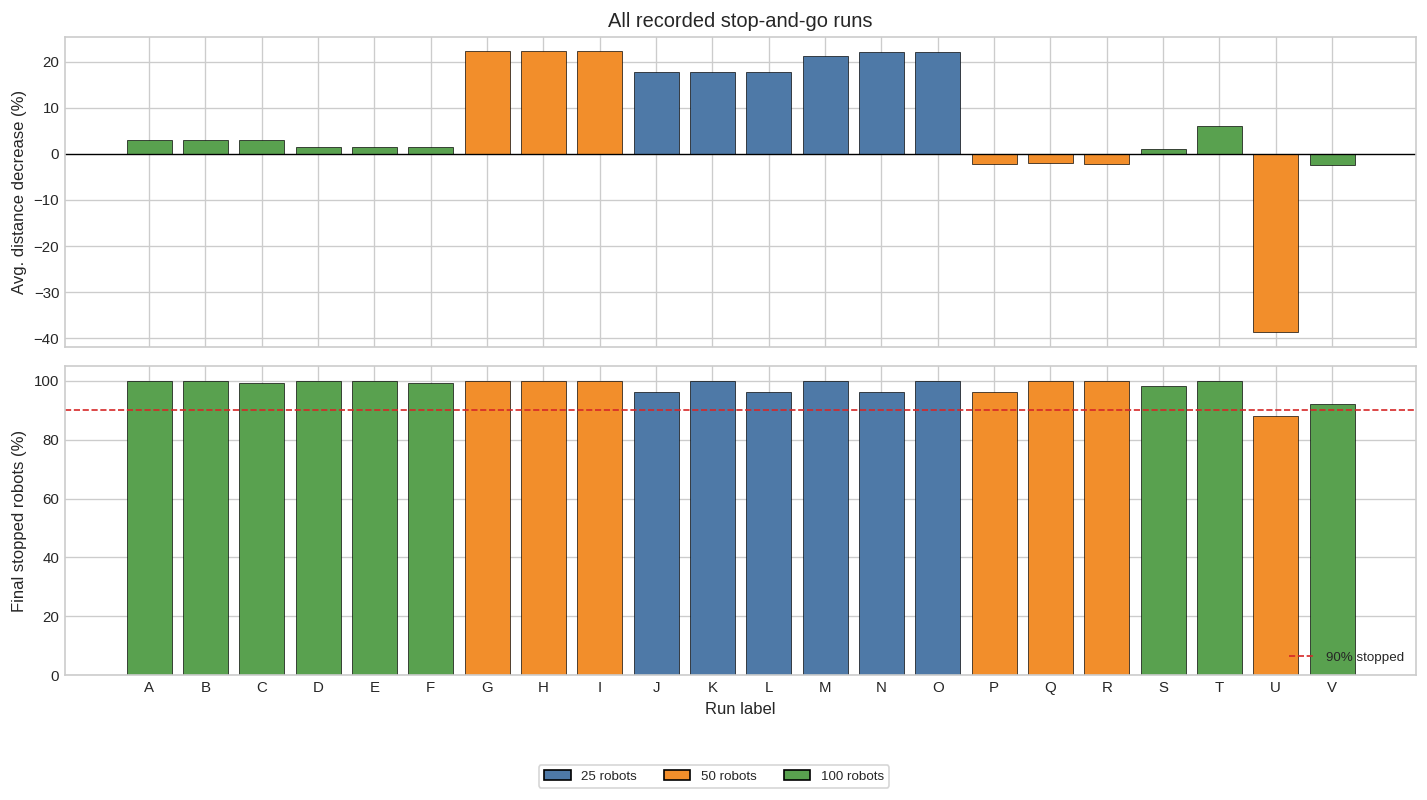

In [11]:
labels = [row['Run'] for row in summary]
bar_colors = [ROBOT_COLORS[row['NumRobots']] for row in summary]

fig, axes = plt.subplots(2, 1, figsize=(12, 6.5), sharex=True)

axes[0].bar(labels, [row['AvgDistanceDecreasePct'] for row in summary], color=bar_colors, edgecolor='black', linewidth=0.4)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_ylabel('Avg. distance decrease (%)')
axes[0].set_title('All recorded stop-and-go runs')

axes[1].bar(labels, [row['FinalStoppedPct'] for row in summary], color=bar_colors, edgecolor='black', linewidth=0.4)
axes[1].axhline(90, color='#D62728', linewidth=1.0, linestyle='--', label='90% stopped')
axes[1].set_ylabel('Final stopped robots (%)')
axes[1].set_xlabel('Run label')
axes[1].set_ylim(0, 105)
axes[1].legend(loc='lower right')

robot_handles = [Patch(facecolor=color, edgecolor='black', label=f'{robots} robots') for robots, color in ROBOT_COLORS.items()]
fig.legend(handles=robot_handles, loc='upper center', ncol=3, frameon=True, bbox_to_anchor=(0.5, 0.02))
fig.tight_layout(rect=(0, 0.05, 1, 1))
save_figure(fig, 'all_runs_summary.png')
plt.show()

## Plot 2 - 100-Robot Parameter Comparison

This plot only compares the 100-robot runs without obstacles. The legend shows the tuple `(stopping distance, max stop time, robots, obstacles)` so the report can discuss parameter effects without putting every detail into the main text.

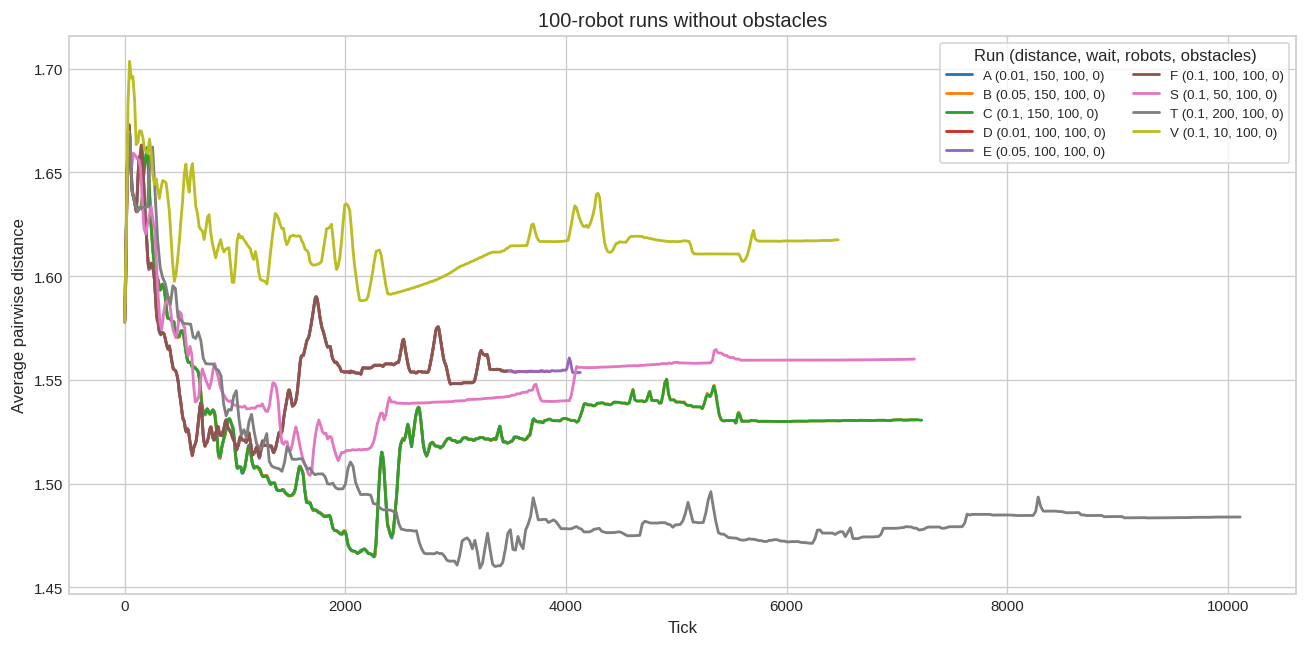

In [12]:
hundred_robot_runs = [
    row for row in summary
    if row['NumRobots'] == 100 and row['NumObstacles'] == 0
]

fig, ax = plt.subplots(figsize=(11, 5.5))

for row in hundred_robot_runs:
    label = row['Run']
    sampled = downsample(runs[label], max_points=450)
    xs = [record['Tick'] for record in sampled]
    ys = [record['AvgDistance'] for record in sampled]
    ax.plot(xs, ys, linewidth=1.7, label=f'{label} {config_tuple(label)}')

ax.set_title('100-robot runs without obstacles')
ax.set_xlabel('Tick')
ax.set_ylabel('Average pairwise distance')
ax.legend(title='Run (distance, wait, robots, obstacles)', ncol=2, frameon=True)
fig.tight_layout()
save_figure(fig, '100_robot_parameter_comparison.png')
plt.show()

## Plot 3 - A Stable Representative 100-Robot Run

The cell below automatically selects a strong 100-robot run without obstacles: it must have at least 90% of robots stopped at the end and a positive decrease in average pairwise distance. The chosen run is then shown with both distance and stopped-robot percentage.

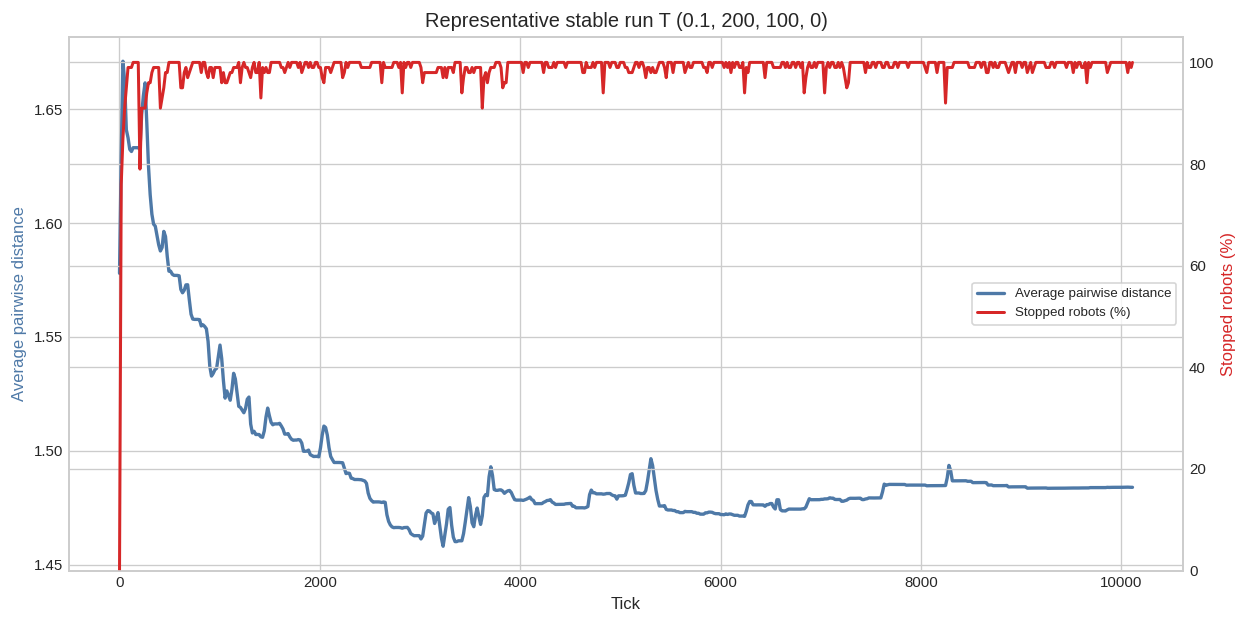

Selected run T with config tuple (0.1, 200, 100, 0)


In [13]:
stable_candidates = [
    row for row in summary
    if row['NumRobots'] == 100
    and row['NumObstacles'] == 0
    and row['FinalStoppedPct'] >= 90.0
    and row['AvgDistanceDecreasePct'] > 0.0
]

if not stable_candidates:
    raise ValueError('No stable candidate found with the current selection rule')

best_run = max(
    stable_candidates,
    key=lambda row: (
        row['AvgDistanceDecreasePct'],
        row['FinalStoppedPct'],
        -row['TailAvgDistanceStd'],
    ),
)

label = best_run['Run']
sampled = downsample(runs[label], max_points=600)
xs = [record['Tick'] for record in sampled]
avg_distance = [record['AvgDistance'] for record in sampled]
stopped_pct = [100.0 * record['StoppedRobots'] / configs[label]['NumRobots'] for record in sampled]

fig, ax_distance = plt.subplots(figsize=(10.5, 5.3))
ax_stopped = ax_distance.twinx()

distance_line = ax_distance.plot(xs, avg_distance, color='#4E79A7', linewidth=2.0, label='Average pairwise distance')
stopped_line = ax_stopped.plot(xs, stopped_pct, color='#D62728', linewidth=1.8, label='Stopped robots (%)')

ax_distance.set_title(f'Representative stable run {label} {config_tuple(label)}')
ax_distance.set_xlabel('Tick')
ax_distance.set_ylabel('Average pairwise distance', color='#4E79A7')
ax_stopped.set_ylabel('Stopped robots (%)', color='#D62728')
ax_stopped.set_ylim(0, 105)

lines = distance_line + stopped_line
ax_distance.legend(lines, [line.get_label() for line in lines], loc='center right', frameon=True)
fig.tight_layout()
save_figure(fig, f'stable_run_{label}.png')
plt.show()

print(f'Selected run {label} with config tuple {config_tuple(label)}')

## Plot 4 - Swarm Size and Convergence Speed

This plot shows how quickly each no-obstacle run reaches a high stopped-robot state. Lower values mean the run reached 90% stopped robots earlier. The labels keep the connection to the CSV files clear.

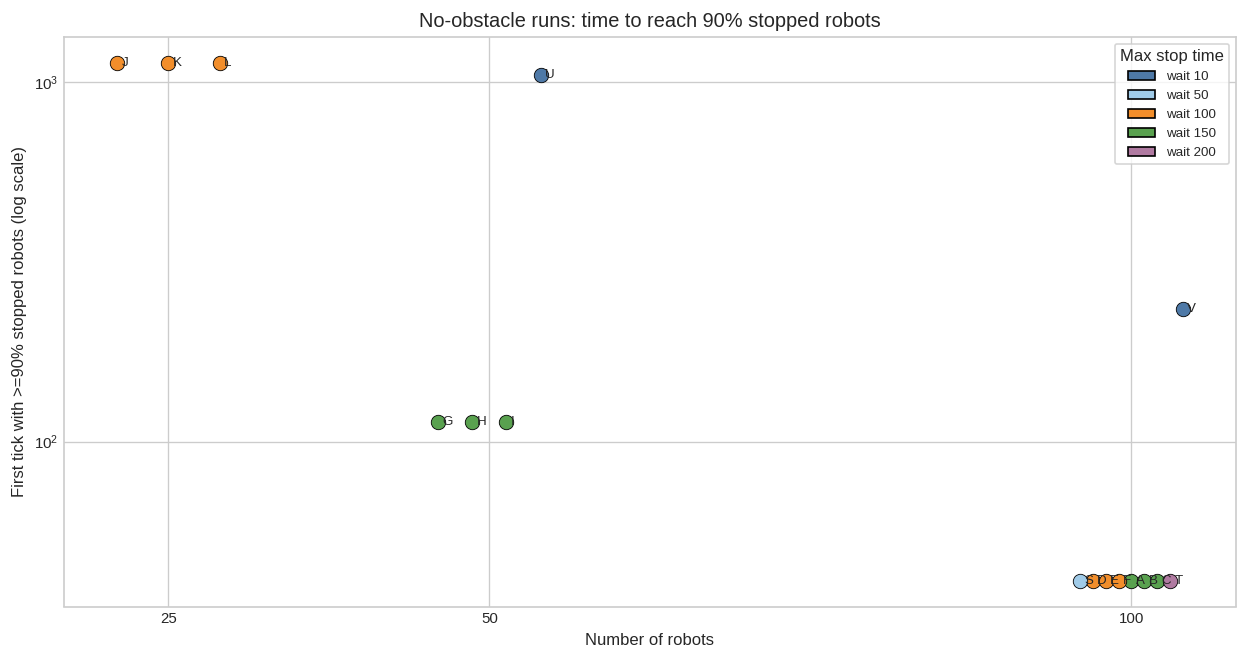

In [14]:
no_obstacle_runs = [
    row for row in summary
    if row['NumObstacles'] == 0 and row['T90StoppedTick'] is not None
]

grouped_by_size = {}
for row in sorted(no_obstacle_runs, key=lambda item: (item['NumRobots'], item['T90StoppedTick'], item['MaxStopTime'], item['StoppingDistance'], item['Run'])):
    grouped_by_size.setdefault(row['NumRobots'], []).append(row)

x_offsets = {}
for num_robots, rows_for_size in grouped_by_size.items():
    if len(rows_for_size) == 1:
        offsets = [0.0]
    else:
        offsets = [-4.0 + (8.0 * index / (len(rows_for_size) - 1)) for index in range(len(rows_for_size))]
    for row, offset in zip(rows_for_size, offsets):
        x_offsets[row['Run']] = offset

fig, ax = plt.subplots(figsize=(10.5, 5.6))

for row in no_obstacle_runs:
    x = row['NumRobots'] + x_offsets[row['Run']]
    color = WAIT_COLORS.get(row['MaxStopTime'], '#777777')
    ax.scatter(x, row['T90StoppedTick'], s=75, color=color, edgecolor='black', linewidth=0.5)
    ax.text(x + 0.35, row['T90StoppedTick'], row['Run'], fontsize=8, va='center')

wait_handles = [
    Patch(facecolor=WAIT_COLORS[wait], edgecolor='black', label=f'wait {wait}')
    for wait in sorted({row['MaxStopTime'] for row in no_obstacle_runs})
    if wait in WAIT_COLORS
]

ax.set_title('No-obstacle runs: time to reach 90% stopped robots')
ax.set_xlabel('Number of robots')
ax.set_ylabel('First tick with >=90% stopped robots (log scale)')
ax.set_xticks(sorted({row['NumRobots'] for row in no_obstacle_runs}))
ax.set_yscale('log')
ax.legend(handles=wait_handles, title='Max stop time', frameon=True)
fig.tight_layout()
save_figure(fig, 'convergence_by_swarm_size.png')
plt.show()